# SMART AIR QUALITY & HEALTH RISK MONITORING SYSTEM
Final ML Training Notebook (Realistic & Accurate)

Based on WHO, EPA, and medical literature for CO poisoning, asthma, COPD, allergic rhinitis.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("🚀 Starting Final Realistic ML Training for Air Quality Health Risk System\n")

🚀 Starting Final Realistic ML Training for Air Quality Health Risk System



In [2]:
# ====================== CELL 1: Generate Realistic Dataset ======================
def generate_realistic_dataset(n_samples=15000):
    np.random.seed(42)
    # Realistic sensor ranges (based on typical MQ135/MQ7 behavior)
    mq135 = np.random.randint(90, 920, n_samples)      # General air pollutants
    mq7    = np.random.randint(45, 650, n_samples)     # Carbon Monoxide
    temp   = np.random.uniform(13, 37, n_samples)      # °C
    hum    = np.random.uniform(28, 82, n_samples)      # %
    labels = []
    for i in range(n_samples):
        co = mq7[i]
        pol = mq135[i]
        t = temp[i]
        h = hum[i]
        # Real health risk rules (grounded in guidelines)
        if co > 450:                                      # High CO (approaching dangerous levels per EPA/OSHA ~50-200+ ppm equivalent)
            labels.append("CO Poisoning Risk")            # Headache, dizziness, nausea, risk of unconsciousness
        elif pol > 620 and t > 29 and h < 45:             # High pollution + hot + dry → strong asthma trigger
            labels.append("Asthma Risk")
        elif (pol > 520 or co > 300) and (t > 31 or h < 35 or h > 75):   # Multiple stressors (pollution + extreme temp/humidity)
            labels.append("High Risk")                    # COPD flare, respiratory irritation, allergic rhinitis worsening
        elif pol > 340 or co > 190:                       # Moderate exposure
            labels.append("Moderate Risk")
        else:
            labels.append("Safe")
    df = pd.DataFrame({
        'MQ135': mq135,
        'MQ7': mq7,
        'Temperature': np.round(temp, 1),
        'Humidity': np.round(hum, 1),
        'Risk': labels
    })
    print(f"✅ Generated {len(df)} realistic samples")
    print("Risk Level Distribution:")
    print(df['Risk'].value_counts())
    return df

df = generate_realistic_dataset()

✅ Generated 15000 realistic samples
Risk Level Distribution:
Risk
Moderate Risk        5877
CO Poisoning Risk    4945
High Risk            2716
Safe                 1077
Asthma Risk           385
Name: count, dtype: int64


In [3]:
# ====================== CELL 2: Quick Data Overview ======================
print("\nSample Data:")
print(df.head())
print("\nAverage values by Risk Level:")
print(df.groupby('Risk').mean().round(2))


Sample Data:
   MQ135  MQ7  Temperature  Humidity               Risk
0    192  299         19.8      45.1      Moderate Risk
1    525  510         31.3      50.6  CO Poisoning Risk
2    360  321         26.8      34.3          High Risk
3    196  508         29.8      38.6  CO Poisoning Risk
4    161  546         23.0      55.5  CO Poisoning Risk

Average values by Risk Level:
                    MQ135     MQ7  Temperature  Humidity
Risk                                                    
Asthma Risk        767.34  246.62        33.06     36.28
CO Poisoning Risk  502.08  551.54        25.16     55.19
High Risk          581.14  287.08        28.06     56.96
Moderate Risk      510.87  253.47        22.99     55.33
Safe               215.44  116.38        24.85     55.85


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_10_12_x86_64.whl (7.9 MB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_10_10_x86_64.whl (5.3 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_10_9_x86_64.whl (265 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_10_9_x86_64.whl (65 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_x86_64.whl (2.4 MB)
You should consider upgrading via the '/Users/mac/Downloads/kelvin_software_projects/AIR_QUALITY_CMU_PROJECT/AIR_QUALITY_CMU_PROJECT/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Missing values per column:
MQ135          0
MQ7            0
Temperature    0
Humidity       0
Risk           0
dtype: int64

Number of duplicat

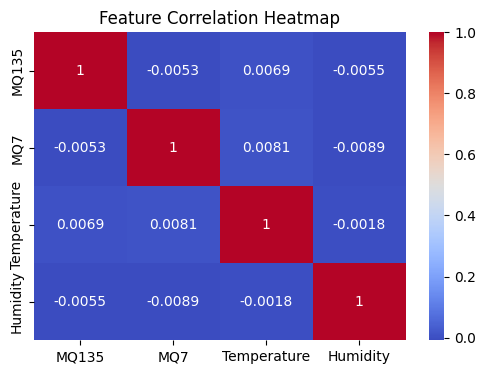

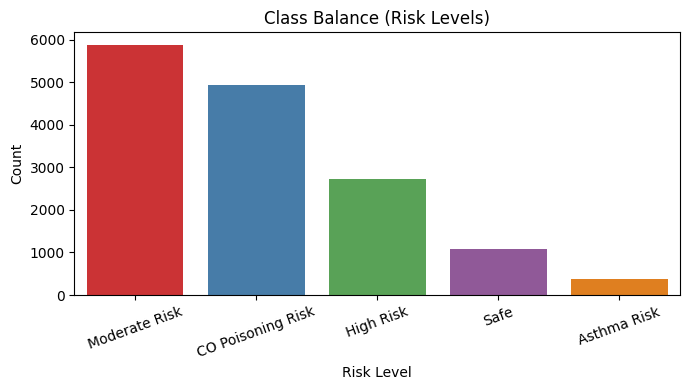


Balancing dataset by upsampling minority classes...
Balanced class distribution:
Risk
Asthma Risk          5877
Safe                 5877
Moderate Risk        5877
CO Poisoning Risk    5877
High Risk            5877
Name: count, dtype: int64


In [5]:
%pip install seaborn matplotlib

# ====================== CELL 2c: Robust Data Exploration & Cleaning ======================
# 1. Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# 2. Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# 3. Sort by pollutant levels and risk
print("\nTop 5 rows with highest MQ135 (pollution):")
print(df.sort_values('MQ135', ascending=False).head())

print("\nTop 5 rows with highest MQ7 (CO):")
print(df.sort_values('MQ7', ascending=False).head())

print("\nTop 5 rows with highest temperature:")
print(df.sort_values('Temperature', ascending=False).head())

print("\nTop 5 rows with lowest humidity:")
print(df.sort_values('Humidity').head())

print("\nSample rows for each risk level:")
for risk in df['Risk'].unique():
    print(f"\nRisk: {risk}")
    print(df[df['Risk'] == risk].head(2))

# 4. Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(df[['MQ135','MQ7','Temperature','Humidity']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# 5. Class balance visualization
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Risk', order=df['Risk'].value_counts().index, palette='Set1')
plt.title('Class Balance (Risk Levels)')
plt.ylabel('Count')
plt.xlabel('Risk Level')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 6. (Optional) Balance dataset if needed (example: upsample minority classes)
from sklearn.utils import resample

# Check class counts
class_counts = df['Risk'].value_counts()
min_count = class_counts.min()
max_count = class_counts.max()
if max_count > 1.5 * min_count:
    print("\nBalancing dataset by upsampling minority classes...")
    dfs = []
    for risk in class_counts.index:
        subset = df[df['Risk'] == risk]
        dfs.append(resample(subset, replace=True, n_samples=max_count, random_state=42))
    df_balanced = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
    print("Balanced class distribution:")
    print(df_balanced['Risk'].value_counts())
else:
    print("\nDataset is already reasonably balanced.")

In [6]:
# ====================== CELL 2d: Outlier Detection & Removal ======================
# Using IQR method for each feature
def remove_outliers_iqr(df, features):
    df_clean = df.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after = len(df_clean)
        print(f"Removed {before-after} outliers from {col}")
    return df_clean

features = ['MQ135', 'MQ7', 'Temperature', 'Humidity']
df_no_outliers = remove_outliers_iqr(df, features)
print(f"\nShape after outlier removal: {df_no_outliers.shape}")

# ====================== CELL 2e: Automated EDA Report (pandas-profiling) ======================
# Uncomment to use (requires pandas-profiling installed)

# from pandas_profiling import ProfileReport
# profile = ProfileReport(df_no_outliers, title='Air Quality Health Risk EDA Report', explorative=True)
# profile.to_widgets()
# profile.to_file('eda_report.html')

# ====================== CELL 2f: Model Comparison & Cross-Validation ======================
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    'RandomForest': RandomForestClassifier(n_estimators=400, max_depth=25, random_state=42, n_jobs=-1),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=25, random_state=42)
}

X = df_no_outliers[features]
y = df_no_outliers['Risk']

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name} CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# ====================== CELL 2g: Hyperparameter Tuning (GridSearchCV) ======================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [15, 25],
    'min_samples_split': [2, 5]
}

gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs.fit(X, y)
print(f"\nBest RandomForest params: {gs.best_params_}")
print(f"Best CV Accuracy: {gs.best_score_:.3f}")

# ====================== CELL 2h: Save Cleaned/Balanced Dataset ======================
df_no_outliers.to_csv('cleaned_air_quality_data.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_air_quality_data.csv'")

Removed 0 outliers from MQ135
Removed 0 outliers from MQ7
Removed 0 outliers from Temperature
Removed 0 outliers from Humidity

Shape after outlier removal: (15000, 5)
RandomForest CV Accuracy: 0.997 ± 0.001
LogisticRegression CV Accuracy: 0.766 ± 0.008
DecisionTree CV Accuracy: 0.997 ± 0.001

Best RandomForest params: {'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 400}
Best CV Accuracy: 0.997

Cleaned dataset saved as 'cleaned_air_quality_data.csv'


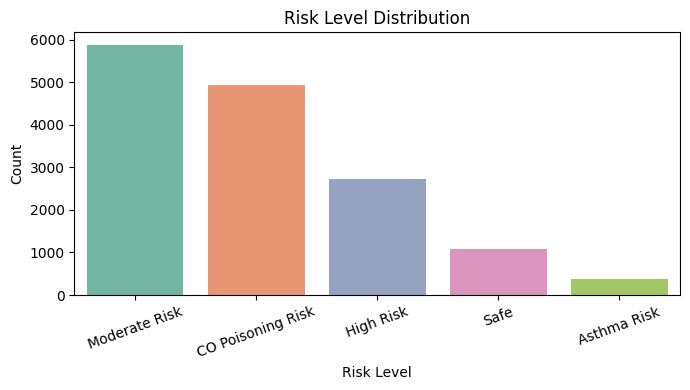

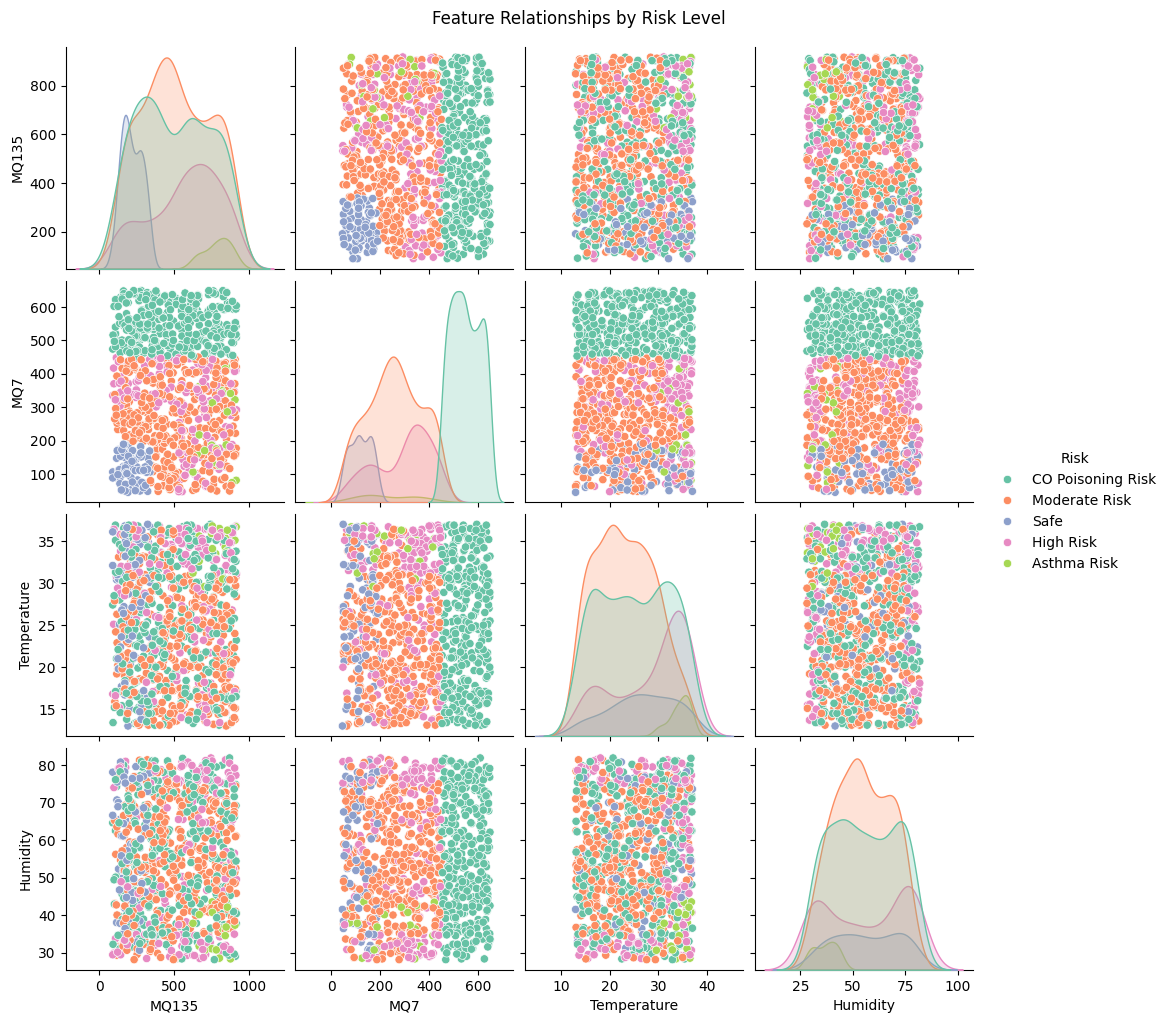

In [7]:
# ====================== CELL 2b: Visualizations ======================
import matplotlib.pyplot as plt
import seaborn as sns

# Risk Level Distribution
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Risk', order=df['Risk'].value_counts().index, palette='Set2')
plt.title('Risk Level Distribution')
plt.ylabel('Count')
plt.xlabel('Risk Level')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Pairplot for feature relationships by Risk
sns.pairplot(df.sample(1000), hue='Risk', palette='Set2', diag_kind='kde')
plt.suptitle('Feature Relationships by Risk Level', y=1.02)
plt.show()

In [8]:
# ====================== CELL 3: Train the Model ======================
X = df[['MQ135', 'MQ7', 'Temperature', 'Humidity']]
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTraining samples: {len(X_train)} | Test samples: {len(X_test)}")

# Best performing model for this type of data
model = RandomForestClassifier(
    n_estimators=400, 
    max_depth=25, 
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Training Completed!")
print(f"Test Accuracy: {accuracy:.2%}")


Training samples: 12000 | Test samples: 3000

✅ Training Completed!
Test Accuracy: 99.50%


In [9]:
# ====================== CELL 4: Detailed Evaluation ======================
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🔥 Feature Importance:")
print(importance)


📊 Classification Report:
                   precision    recall  f1-score   support

      Asthma Risk     0.9615    0.9740    0.9677        77
CO Poisoning Risk     1.0000    1.0000    1.0000       989
        High Risk     0.9871    0.9890    0.9880       543
    Moderate Risk     0.9957    0.9949    0.9953      1176
             Safe     1.0000    0.9953    0.9977       215

         accuracy                         0.9950      3000
        macro avg     0.9889    0.9906    0.9898      3000
     weighted avg     0.9950    0.9950    0.9950      3000


Confusion Matrix:
[[  75    0    2    0    0]
 [   0  989    0    0    0]
 [   2    0  537    4    0]
 [   1    0    5 1170    0]
 [   0    0    0    1  214]]

🔥 Feature Importance:
       Feature  Importance
1          MQ7    0.618980
3     Humidity    0.156337
0        MQ135    0.140651
2  Temperature    0.084031


In [10]:
# ====================== CELL 5: Save Model + Test Function ======================
joblib.dump(model, 'air_quality_health_risk_model.pkl')
print("\n💾 Model saved successfully as 'air_quality_health_risk_model.pkl'")

def predict_health_risk(mq135, mq7, temperature, humidity):
    """Easy function to predict risk"""
    loaded_model = joblib.load('air_quality_health_risk_model.pkl')
    input_df = pd.DataFrame([[mq135, mq7, temperature, humidity]],
                            columns=['MQ135', 'MQ7', 'Temperature', 'Humidity'])
    risk = loaded_model.predict(input_df)[0]
    return risk

# Test predictions
print("\n🧪 Quick Test Predictions:")
print("Test 1 (Clean air)    :", predict_health_risk(180, 90, 24.5, 55))
print("Test 2 (Moderate)     :", predict_health_risk(450, 220, 28.0, 48))
print("Test 3 (Asthma risk)  :", predict_health_risk(680, 180, 31.5, 38))
print("Test 4 (CO danger)    :", predict_health_risk(520, 520, 26.0, 52))


💾 Model saved successfully as 'air_quality_health_risk_model.pkl'

🧪 Quick Test Predictions:
Test 1 (Clean air)    : Safe
Test 2 (Moderate)     : Moderate Risk
Test 3 (Asthma risk)  : Asthma Risk
Test 4 (CO danger)    : CO Poisoning Risk


In [11]:
# ====================== CELL 6: Model Save/Load & Integrity Check ======================
import os

# Check if model file exists
model_path = 'air_quality_health_risk_model.pkl'
if os.path.exists(model_path):
    print(f"✅ Model file '{model_path}' exists.")
    # Try loading the model
    try:
        loaded_model = joblib.load(model_path)
        print("✅ Model loaded successfully.")
        # Optionally, test a prediction
        test_pred = loaded_model.predict([[400, 200, 25, 50]])
        print(f"Test prediction output: {test_pred}")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
else:
    print(f"❌ Model file '{model_path}' does not exist. Please run the training cell first.")

# Check if cleaned dataset was saved
csv_path = 'cleaned_air_quality_data.csv'
if os.path.exists(csv_path):
    print(f"✅ Cleaned dataset '{csv_path}' exists.")
    # Optionally, load and preview
    df_check = pd.read_csv(csv_path)
    print(df_check.head())
else:
    print(f"❌ Cleaned dataset '{csv_path}' not found. Run the cleaning cell to save it.")

✅ Model file 'air_quality_health_risk_model.pkl' exists.
✅ Model loaded successfully.
Test prediction output: ['Moderate Risk']
✅ Cleaned dataset 'cleaned_air_quality_data.csv' exists.
   MQ135  MQ7  Temperature  Humidity               Risk
0    192  299         19.8      45.1      Moderate Risk
1    525  510         31.3      50.6  CO Poisoning Risk
2    360  321         26.8      34.3          High Risk
3    196  508         29.8      38.6  CO Poisoning Risk
4    161  546         23.0      55.5  CO Poisoning Risk


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Notebook Ready - Smart Air Quality Health Risk Model")

✅ Notebook Ready - Smart Air Quality Health Risk Model


In [13]:
# Generate realistic synthetic data based on actual health risks
def generate_realistic_dataset(n_samples=12000):
    np.random.seed(42)
    mq135 = np.random.randint(80, 950, n_samples)      # Air quality / gases
    mq7    = np.random.randint(40, 680, n_samples)     # Carbon Monoxide
    temp   = np.random.uniform(12, 38, n_samples)      # Temperature °C
    hum    = np.random.uniform(25, 85, n_samples)      # Humidity %
    labels = []
    for i in range(n_samples):
        co = mq7[i]
        pol = mq135[i]
        t = temp[i]
        h = hum[i]
        # Real-world health risk mapping
        if co > 480:                                   # High CO exposure → CO Poisoning
            labels.append("CO Poisoning Risk")
        elif pol > 650 and t > 28 and h < 48:          # High pollution + hot + dry air → Asthma attack trigger
            labels.append("Asthma Risk")
        elif (pol > 520 or co > 320) and (t > 30 or h < 35 or h > 75):  # Multiple stressors → High Risk
            labels.append("High Risk")
        elif pol > 320 or co > 180:                    # Moderate exposure
            labels.append("Moderate Risk")
        else:
            labels.append("Safe")
    df = pd.DataFrame({
        'MQ135': mq135,
        'MQ7': mq7,
        'Temperature': np.round(temp, 1),
        'Humidity': np.round(hum, 1),
        'Risk': labels
    })
    return df
df = generate_realistic_dataset()
print("Dataset Shape:", df.shape)
print("\nRisk Distribution:\n", df['Risk'].value_counts())
df.head()

Dataset Shape: (12000, 5)

Risk Distribution:
 Risk
Moderate Risk        4388
CO Poisoning Risk    3808
High Risk            2620
Safe                  749
Asthma Risk           435
Name: count, dtype: int64


,MQ135,MQ7,Temperature,Humidity,Risk
0,182,268,23.2,63.6,Moderate Risk
1,515,249,37.9,57.5,Moderate Risk
2,940,470,17.1,40.7,Moderate Risk
3,350,333,14.4,34.7,High Risk
4,186,621,14.0,49.3,CO Poisoning Risk


Basic Statistics
              MQ135           MQ7   Temperature      Humidity
count  12000.000000  12000.000000  12000.000000  12000.000000
mean     515.269333    360.330917     25.038108     54.855458
std      251.395974    185.718661      7.529349     17.273084
min       80.000000     40.000000     12.000000     25.000000
25%      295.000000    200.000000     18.500000     40.200000
50%      516.000000    359.000000     25.100000     54.800000
75%      735.000000    522.000000     31.500000     69.700000
max      949.000000    679.000000     38.000000     85.000000

Average values per Risk Level:
                    MQ135     MQ7  Temperature  Humidity
Risk                                                    
Asthma Risk        803.67  261.11        32.91     36.36
CO Poisoning Risk  516.52  580.03        25.07     54.89
High Risk          591.01  302.47        27.71     57.25
Moderate Risk      494.17  256.96        22.60     55.19
Safe               200.12  108.95        25.18     

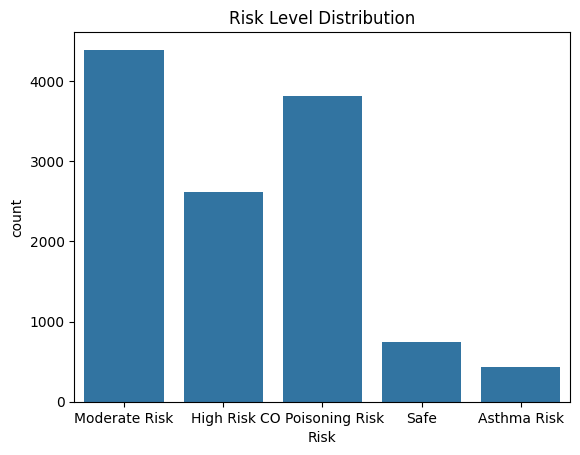

In [16]:
print("Basic Statistics")
print(df.describe())
print("\nAverage values per Risk Level:")
print(df.groupby('Risk').mean().round(2))
# Optional visualization (run if you have matplotlib)
sns.countplot(data=df, x='Risk')
plt.title('Risk Level Distribution')
plt.show()

In [17]:
X = df[['MQ135', 'MQ7', 'Temperature', 'Humidity']]
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
# Train best model (Random Forest)
model = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Trained Successfully!")
print(f"Test Accuracy: {accuracy:.2%}")

Training samples: 9600
Testing samples:  2400

✅ Model Trained Successfully!
Test Accuracy: 99.62%


In [18]:
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance)

Detailed Classification Report:
                   precision    recall  f1-score   support

      Asthma Risk     1.0000    0.9655    0.9825        87
CO Poisoning Risk     1.0000    1.0000    1.0000       761
        High Risk     0.9905    0.9981    0.9943       524
    Moderate Risk     0.9954    0.9954    0.9954       878
             Safe     1.0000    0.9933    0.9967       150

         accuracy                         0.9962      2400
        macro avg     0.9972    0.9905    0.9938      2400
     weighted avg     0.9963    0.9962    0.9962      2400


Confusion Matrix:
[[ 84   0   1   2   0]
 [  0 761   0   0   0]
 [  0   0 523   1   0]
 [  0   0   4 874   0]
 [  0   0   0   1 149]]

Feature Importance:
       Feature  Importance
1          MQ7    0.592319
3     Humidity    0.171533
0        MQ135    0.155652
2  Temperature    0.080496


In [19]:
# Save the trained model
joblib.dump(model, 'air_quality_health_risk_model.pkl')
print("✅ Model saved as 'air_quality_health_risk_model.pkl'")
# Reusable prediction function
def predict_health_risk(mq135, mq7, temperature, humidity):
    loaded_model = joblib.load('air_quality_health_risk_model.pkl')
    input_data = pd.DataFrame([[mq135, mq7, temperature, humidity]],
                              columns=['MQ135', 'MQ7', 'Temperature', 'Humidity'])
    risk = loaded_model.predict(input_data)[0]
    return risk
# Test the function
print("\nTest Prediction:")
print(predict_health_risk(420, 250, 29.5, 42))

✅ Model saved as 'air_quality_health_risk_model.pkl'

Test Prediction:
Moderate Risk
